In [5]:
from ultralytics import YOLO
import cv2
from pathlib import Path

In [6]:
model = YOLO("yolov8m.pt")



## Baseline diagnostics (before fine-tuning)

Measure the pretrained `yolov8m.pt` on the BDD100K val set so we have a "before" to compare against.

**Key caveat:** `yolov8m.pt` is COCO-trained — 80 classes in a *different* index order than our 10 BDD classes. Scoring it directly against BDD labels would be meaningless (e.g. COCO `bus=5` vs BDD `train=5`), so we remap COCO→BDD ids (`COCO_TO_BDD`) first. BDD `rider` and `traffic sign` have no COCO counterpart and will read ~0 until fine-tuning.

Three diagnostics: **speed** (FPS), **qualitative** (pred vs GT gallery), **quantitative** (per-class AP@0.5). The same `evaluate_map50` runs on the fine-tuned model later (with `remap=None`) for an apples-to-apples delta.

In [7]:
# ---- diagnostics config ----
import torch
import numpy as np
import random

# resolve paths whether the notebook runs from repo root or notebooks/
DATA = next(p for p in [Path("data/bdd_yolo"), Path("../data/bdd_yolo")] if p.exists())
VAL_IMG = DATA / "images" / "val"
VAL_LBL = DATA / "labels" / "val"
YAML = DATA / "bdd100k.yaml"

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
IMG_W, IMG_H = 1280, 720

BDD_NAMES = ["person", "rider", "car", "truck", "bus", "train",
             "motorcycle", "bicycle", "traffic light", "traffic sign"]

# yolov8m.pt is COCO-trained (80 classes) with DIFFERENT indices than our BDD set.
# Map COCO class id -> BDD class id for the overlapping classes so the "before"
# baseline is scored fairly. BDD 'rider' (1) and 'traffic sign' (9) have no COCO
# equivalent -> they will read ~0 AP until fine-tuning (expected, and informative).
COCO_TO_BDD = {
    0: 0,   # person       -> person
    1: 7,   # bicycle      -> bicycle
    2: 2,   # car          -> car
    3: 6,   # motorcycle   -> motorcycle
    5: 4,   # bus          -> bus
    6: 5,   # train        -> train
    7: 3,   # truck        -> truck
    9: 8,   # traffic light-> traffic light
}

print("data:", DATA.resolve())
print("device:", DEVICE, "| val images:", len(list(VAL_IMG.glob('*.jpg'))))

data: /Users/utsavagarwal/dashcam-perception/data/bdd_yolo
device: mps | val images: 10000


In [8]:
# ---- speed / latency (a dashcam model needs to keep up with the video) ----
import time

speed_imgs = sorted(VAL_IMG.glob("*.jpg"))[:50]
model.predict(str(speed_imgs[0]), imgsz=640, device=DEVICE, verbose=False)  # warmup

t0 = time.perf_counter()
for p in speed_imgs:
    model.predict(str(p), imgsz=640, device=DEVICE, verbose=False)
dt = (time.perf_counter() - t0) / len(speed_imgs)
print(f"avg inference: {dt * 1000:.1f} ms/img  ->  {1 / dt:.1f} FPS  @imgsz=640 on {DEVICE}")

avg inference: 35.6 ms/img  ->  28.1 FPS  @imgsz=640 on mps


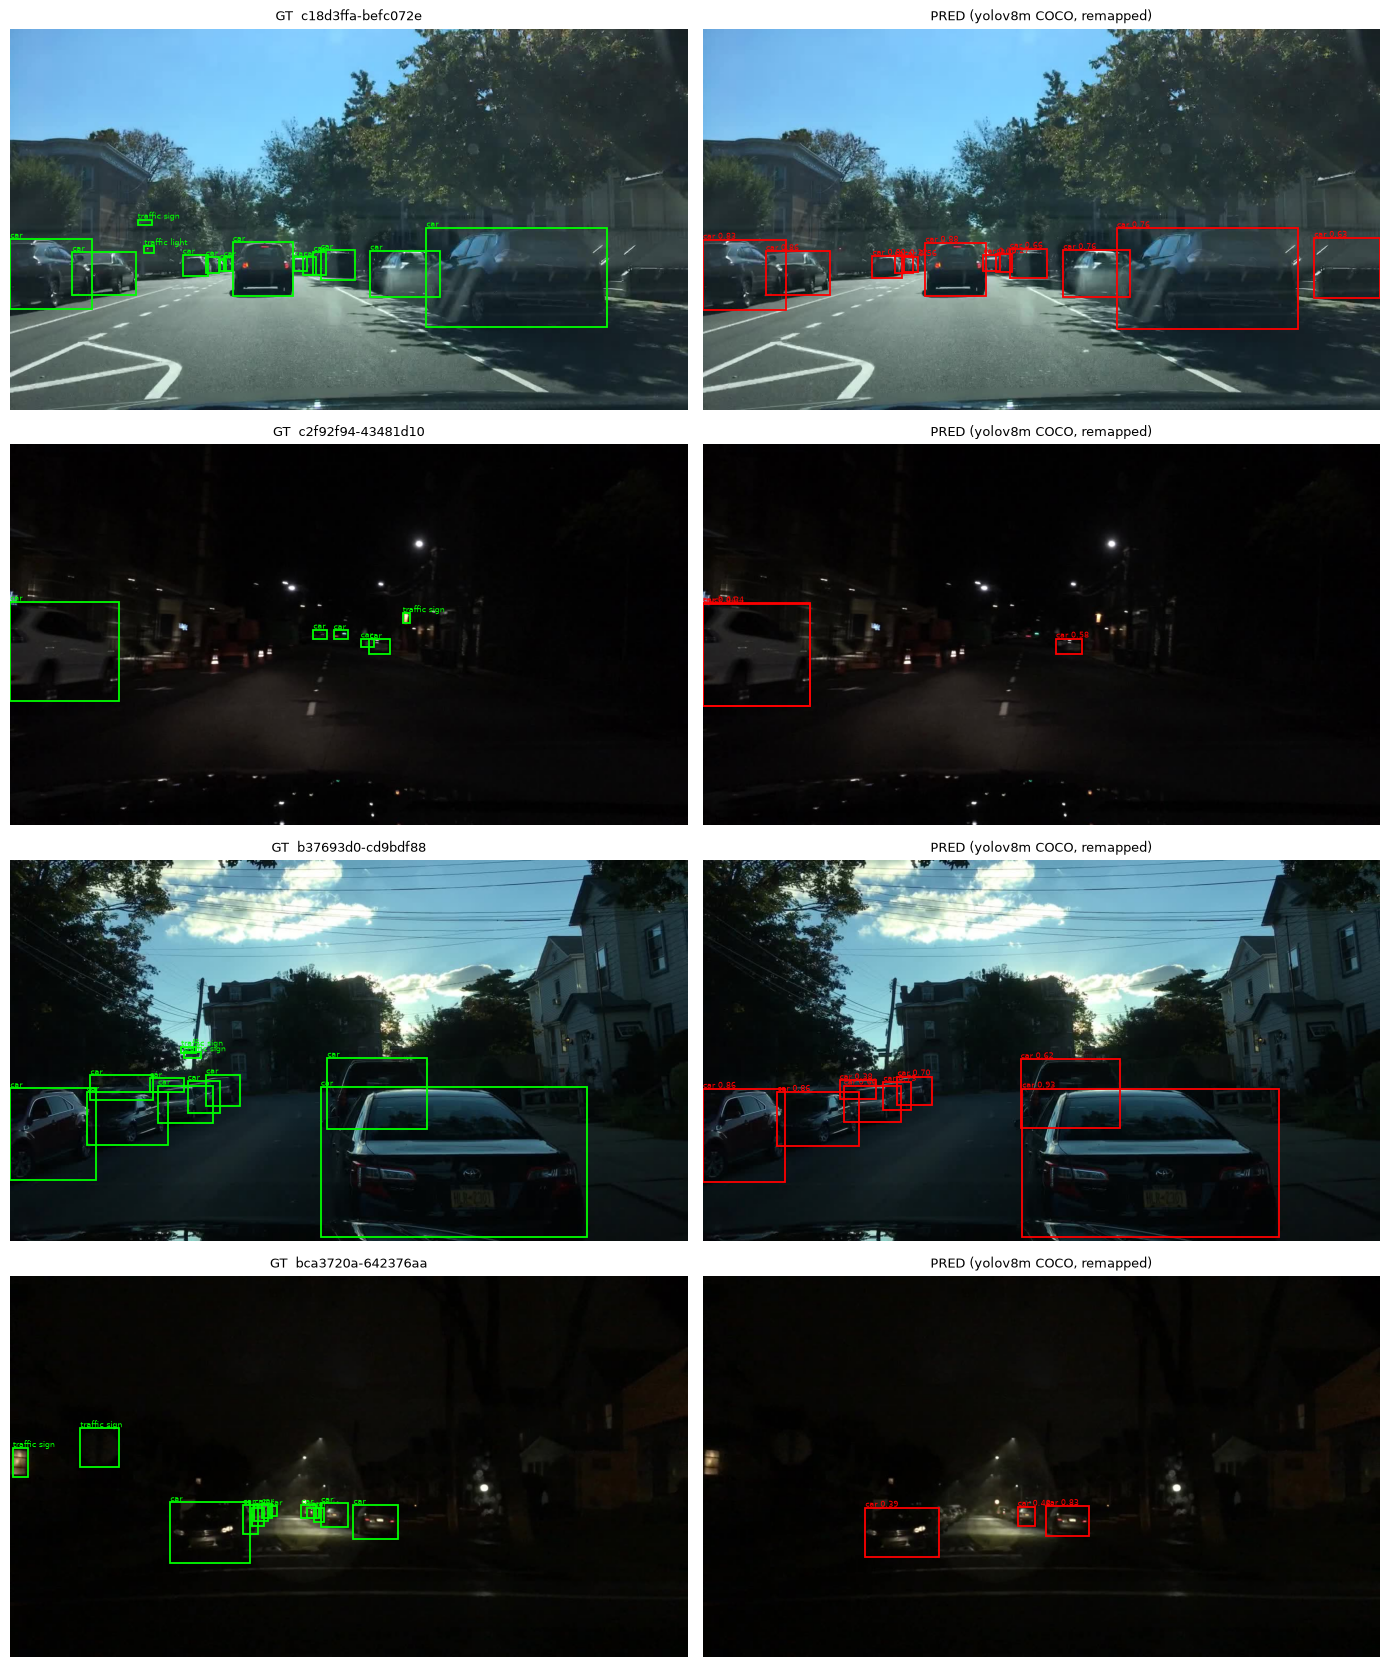

In [9]:
# ---- qualitative: predictions (red) vs ground truth (green) side by side ----
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def load_gt(stem):
    """Read a BDD-YOLO label file -> [(cls, x, y, w, h), ...] in pixels."""
    f = VAL_LBL / f"{stem}.txt"
    boxes = []
    if f.exists() and f.stat().st_size:
        for line in f.read_text().splitlines():
            c, xc, yc, w, h = line.split()
            c = int(c); xc, yc, w, h = float(xc), float(yc), float(w), float(h)
            boxes.append((c, (xc - w / 2) * IMG_W, (yc - h / 2) * IMG_H,
                          w * IMG_W, h * IMG_H))
    return boxes

def show_pred_vs_gt(model, stems, remap=None, conf=0.25, title=""):
    rows = len(stems)
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4.2 * rows))
    if rows == 1:
        axes = axes[None, :]
    for r, stem in enumerate(stems):
        img = cv2.cvtColor(cv2.imread(str(VAL_IMG / f"{stem}.jpg")), cv2.COLOR_BGR2RGB)
        # ground truth
        axes[r, 0].imshow(img); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"GT  {stem}", fontsize=9)
        for c, x, y, w, h in load_gt(stem):
            axes[r, 0].add_patch(patches.Rectangle((x, y), w, h, fill=False,
                                                   edgecolor="lime", lw=1.3))
            axes[r, 0].text(x, y - 2, BDD_NAMES[c], color="lime", fontsize=6)
        # predictions
        res = model.predict(str(VAL_IMG / f"{stem}.jpg"), imgsz=640,
                            conf=conf, device=DEVICE, verbose=False)[0]
        axes[r, 1].imshow(img); axes[r, 1].axis("off")
        axes[r, 1].set_title(f"PRED {title}", fontsize=9)
        for box in res.boxes:
            cid = int(box.cls)
            if remap is not None:
                if cid not in remap:
                    continue
                cid = remap[cid]
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            axes[r, 1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                   fill=False, edgecolor="red", lw=1.3))
            axes[r, 1].text(x1, y1 - 2, f"{BDD_NAMES[cid]} {float(box.conf):.2f}",
                            color="red", fontsize=6)
    plt.tight_layout()
    plt.savefig("diag_pred_vs_gt.png", dpi=110)
    plt.show()

random.seed(0)
samples = [p.stem for p in random.sample(sorted(VAL_IMG.glob("*.jpg")), 4)]
show_pred_vs_gt(model, samples, remap=COCO_TO_BDD, title="(yolov8m COCO, remapped)")

In [10]:
# ---- quantitative: per-class AP@0.5 (works for COCO-remapped OR native-BDD models) ----
def _iou_matrix(a, b):
    """IoU between two sets of xyxy boxes. a:(N,4) b:(M,4) -> (N,M)."""
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)

def _ap(recall, precision):
    """VOC all-point interpolation: area under the monotonic PR envelope."""
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

def evaluate_map50(model, stems, remap=None, conf=0.001, iou_thr=0.5):
    """Per-class AP@0.5 vs BDD ground truth. remap: pred class id -> BDD id
    (drop preds not in the map). Pass remap=None for a native-BDD model."""
    n = len(BDD_NAMES)
    preds = {c: [] for c in range(n)}   # (score, img_idx, xyxy)
    gts = {c: {} for c in range(n)}     # img_idx -> [xyxy,...]
    gt_count = {c: 0 for c in range(n)}
    for i, stem in enumerate(stems):
        for c, x, y, w, h in load_gt(stem):
            gts[c].setdefault(i, []).append([x, y, x + w, y + h])
            gt_count[c] += 1
        res = model.predict(str(VAL_IMG / f"{stem}.jpg"), imgsz=640,
                            conf=conf, device=DEVICE, verbose=False)[0]
        for box in res.boxes:
            cid = int(box.cls)
            if remap is not None:
                if cid not in remap:
                    continue
                cid = remap[cid]
            preds[cid].append((float(box.conf), i, box.xyxy[0].tolist()))

    aps = {}
    for c in range(n):
        if gt_count[c] == 0:
            aps[c] = float("nan")
            continue
        ranked = sorted(preds[c], key=lambda t: -t[0])
        gt_arr = {i: np.array(v) for i, v in gts[c].items()}
        matched = {i: set() for i in gt_arr}
        tp = np.zeros(len(ranked)); fp = np.zeros(len(ranked))
        for k, (_, i, box) in enumerate(ranked):
            if i not in gt_arr:
                fp[k] = 1; continue
            ious = _iou_matrix(np.array([box]), gt_arr[i])[0]
            j = int(np.argmax(ious))
            if ious[j] >= iou_thr and j not in matched[i]:
                tp[k] = 1; matched[i].add(j)
            else:
                fp[k] = 1
        tpc, fpc = np.cumsum(tp), np.cumsum(fp)
        recall = tpc / (gt_count[c] + 1e-9)
        precision = tpc / (tpc + fpc + 1e-9)
        aps[c] = _ap(recall, precision)
    return aps

In [11]:
# ---- run the COCO baseline (remapped) over a val subset ----
# bump N_EVAL toward len(all_val)=10000 for a tighter estimate; CPU/MPS is slow so start small.
N_EVAL = 500
random.seed(0)
all_val = sorted(p.stem for p in VAL_IMG.glob("*.jpg"))
eval_stems = random.sample(all_val, min(N_EVAL, len(all_val)))

baseline = evaluate_map50(model, eval_stems, remap=COCO_TO_BDD)

print(f"=== yolov8m (COCO, remapped) baseline on {len(eval_stems)} val images ===")
for c, name in enumerate(BDD_NAMES):
    v = baseline[c]
    note = "  <- no COCO equivalent" if c in (1, 9) else ""
    print(f"  {name:14s} AP@0.5 = " + ("  n/a" if np.isnan(v) else f"{v:.3f}") + note)
print(f"  {'mAP@0.5':14s}        = {np.nanmean(list(baseline.values())):.3f}"
      f"  (mean over classes with GT)")

=== yolov8m (COCO, remapped) baseline on 500 val images ===
  person         AP@0.5 = 0.516
  rider          AP@0.5 = 0.000  <- no COCO equivalent
  car            AP@0.5 = 0.612
  truck          AP@0.5 = 0.458
  bus            AP@0.5 = 0.488
  train          AP@0.5 = 0.500
  motorcycle     AP@0.5 = 0.395
  bicycle        AP@0.5 = 0.292
  traffic light  AP@0.5 = 0.239
  traffic sign   AP@0.5 = 0.000  <- no COCO equivalent
  mAP@0.5               = 0.350  (mean over classes with GT)


In [12]:
ft = YOLO("yolov8m.pt")

In [17]:
ft.train(data = str(YAML),
         epochs = 10,
         imgsz = 416,
         batch = 8, 
         device = DEVICE,
         project = "runs/detect",
         name = "bdd_ft_fast")

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.77 🚀 Python-3.13.7 torch-2.12.1 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/bdd_yolo/bdd100k.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0,

/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10      14.4G          0          0          0          0        416: 100% ━━━━━━━━━━━━ 8750/8750 1.6it/s 1:33:290.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 4.5it/s 2:180.2ss
                   all      10000          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10      14.4G          0          0          0          0        416: 100% ━━━━━━━━━━━━ 8750/8750 1.6it/s 1:30:560.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 4.5it/s 2:180.2ss
                   all      10000          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...

/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:877: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



10 epochs completed in 15.472 hours.
Optimizer stripped from /Users/utsavagarwal/dashcam-perception/notebooks/runs/detect/runs/detect/bdd_ft_fast-2/weights/last.pt, 52.0MB
Optimizer stripped from /Users/utsavagarwal/dashcam-perception/notebooks/runs/detect/runs/detect/bdd_ft_fast-2/weights/best.pt, 52.0MB

Validating /Users/utsavagarwal/dashcam-perception/notebooks/runs/detect/runs/detect/bdd_ft_fast-2/weights/best.pt...
Ultralytics 8.4.77 🚀 Python-3.13.7 torch-2.12.1 MPS (Apple M4)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 5.0it/s 2:040.2ss


/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:695: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/utsavagarwal/dashcam-perception/venv/lib/python3.13/site-packages/ultralytics/utils/metrics.py:741: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
/Users/utsavagarwal/dashcam-pe

                   all      10000          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.1ms preprocess, 6.5ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /Users/utsavagarwal/dashcam-perception/notebooks/runs/detect/runs/detect/bdd_ft_fast-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1444f4410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0